In [26]:
import shutil
shutil.unpack_archive('maternal-health-and-high-risk-pregnancy-dataset.zip', 'mh1')
shutil.unpack_archive('maternal-health-risk-with-augmented-features.zip', 'mh2')

import pandas as pd
df1, df2 = pd.read_excel('mh1/Book2.xlsx'),pd.read_csv('mh2/Maternal_Health_Risk_Augmented.csv')

In [27]:
print(df1.columns, df2.columns, df1.loc[0].values, sep='\n')
df1 = df1.rename(columns = dict(zip(df1.columns, df1.loc[0].tolist())))
# Comprehensive mapping for df1 columns to English/df2 equivalents
column_mapping = {
    'Name': 'Name',
    'Age': 'Age',
    'Gravida': 'Gravida',
    'TiTi Tika': 'TT_Vaccine',
    'গর্ভকাল': 'GestationalAge',          
    'ওজন': 'Weight',
    'উচ্চতা': 'Height',
    'রক্ত চাপ': 'BloodPressure',          # We will split this into Systolic/Diastolic next
    'রক্তস্বল্পতা': 'Anemia',
    'জন্ডিস': 'Jaundice',
    'গর্ভস্হ শিশু অবস্থান': 'FetalPosition',
    'গর্ভস্হ শিশু নাড়াচাড়া': 'FetalMovement',
    'গর্ভস্হ শিশু হৃৎস্পন্দন': 'HeartRate', # Matches df2 'HeartRate'
    'প্রসাব পরিক্ষা এলবুমিন': 'Urine_Albumin',
    'প্রসাব পরিক্ষা সুগার': 'Urine_Sugar',  
    'VDRL': 'VDRL',
    'HRsAG': 'HBsAg',                     # Correcting typo from HRsAG to HBsAg
    'ঝুকিপূর্ণ গর্ভ': 'IsAtRisk'         # Matches df2 'RiskLevel'
}

# Let's apply the renaming to df1
df1 = df1.rename(columns=column_mapping)
df1 = df1.drop(0, axis=0)

Index(['ANCC REGISTER', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17'],
      dtype='object')
Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel', 'sleep_hours', 'phys_activity_score', 'stress_score',
       'education_level', 'income_category', 'urban_rural',
       'diet_quality_score', 'hemoglobin_g_dL', 'iron_supplement',
       'folic_supplement', 'diet_adherence'],
      dtype='object')
['Name' 'Age' 'Gravida' 'TiTi Tika' 'গর্ভকাল' 'ওজন' 'উচ্চতা' 'রক্ত চাপ'
 'রক্তস্বল্পতা' 'জন্ডিস' 'গর্ভস্হ শিশু অবস্থান' 'গর্ভস্হ শিশু নাড়াচাড়া'
 'গর্ভস্হ শিশু হৃৎস্পন্দন' 'প্রসাব পরিক্ষা এলবুমিন' 'প্রসাব পরিক্ষা সুগার'
 'VDRL' 'HRsAG' 'ঝুকিপূর্ণ গর্ভ']


In [28]:
# Returns the count of NaN values for each column
df1.isna().sum()

Name                0
Age                 0
Gravida             0
TT_Vaccine          0
GestationalAge      0
Weight              0
Height              0
BloodPressure       0
Anemia            875
Jaundice          986
FetalPosition       0
FetalMovement       0
HeartRate           0
Urine_Albumin     864
Urine_Sugar         0
VDRL                0
HBsAg               0
IsAtRisk            0
dtype: int64

In [29]:
df1.head()

,Name,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,Anemia,Jaundice,FetalPosition,FetalMovement,HeartRate,Urine_Albumin,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,Rituporna,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,Normal,140m,NaN,Yes,Negative,Negative,Yes
2,Moina,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,No
3,Rabeya,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,Normal,120m,NaN,Yes,Negative,Negative,Yes
4,Shorna,22,1st,3rd,35 week,51 kg,5.4'',110/65,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,Yes
5,Tania Akter,20,1st,2nd,30 week,53 kg,5.2'',100/55,NaN,NaN,Normal,Normal,125m,NaN,Yes,Negative,Negative,No


In [30]:
df2.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,sleep_hours,phys_activity_score,stress_score,education_level,income_category,urban_rural,diet_quality_score,hemoglobin_g_dL,iron_supplement,folic_supplement,diet_adherence
0,25,130,80,15.0,98.0,86,high risk,8.04,8.23,3.99,Secondary,Medium,Urban,3.92,11.47,1,1,Fair
1,35,140,90,13.0,98.0,70,high risk,6.55,6.67,6.16,Secondary,Medium,Urban,3.95,11.88,1,1,Fair
2,29,90,70,8.0,100.0,80,high risk,6.07,9.30,4.51,Secondary,Low,Rural,2.00,10.32,1,1,Poor
3,30,140,85,7.0,98.0,70,high risk,5.86,6.11,3.86,Tertiary,High,Urban,6.05,11.74,1,0,Good
4,35,120,60,6.1,98.0,76,low risk,6.34,8.57,5.55,Secondary,Low,Rural,3.79,13.74,0,1,Fair


In [31]:
df1 = df1.drop(columns = ['Name', 'Anemia', 'Jaundice', 'Urine_Albumin', 'FetalMovement'])
df1.head()

,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,FetalPosition,HeartRate,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,18,1st,1st,38 week,50 kg,5.3'',100/60,Normal,140m,Yes,Negative,Negative,Yes
2,25,2nd,2nd,38 week,60 kg,5.2'',100/70,Normal,130m,Yes,Positive,Negative,No
3,20,1st,1st,30 week,55 kg,5.0'',100/60,Normal,120m,Yes,Negative,Negative,Yes
4,22,1st,3rd,35 week,51 kg,5.4'',110/65,Normal,130m,Yes,Positive,Negative,Yes
5,20,1st,2nd,30 week,53 kg,5.2'',100/55,Normal,125m,Yes,Negative,Negative,No


In [32]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def vif(X):
    X = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_data

In [33]:
from sklearn.preprocessing import LabelEncoder

def preprocess_df(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    encoders = {col: LabelEncoder() for col in categorical_cols}

    for col in categorical_cols:
        df[col] = encoders[col].fit_transform(df[col])


In [34]:
X1, X2 = df1.drop('IsAtRisk', axis=1), df2.drop('diet_adherence', axis=1)
preprocess_df(X1)
preprocess_df(X2)

In [35]:
vif1, vif2 = vif(X1), vif(X2)

In [36]:
print(vif1, vif2, sep='\n-----------------------------------------\n')

           Feature         VIF
0            const  196.183995
1              Age    1.045725
2          Gravida    1.041597
3       TT_Vaccine    1.092453
4   GestationalAge    1.031512
5           Weight    1.086379
6           Height    1.014561
7    BloodPressure    1.087034
8    FetalPosition    1.008847
9        HeartRate    1.000772
10     Urine_Sugar    1.079164
11            VDRL    1.100712
12           HBsAg    1.107280
-----------------------------------------
                Feature          VIF
0                 const  6776.395169
1                   Age     2.522808
2            SystolicBP     3.024817
3           DiastolicBP     3.327523
4                    BS     1.749385
5              BodyTemp     1.151964
6             HeartRate     1.069407
7             RiskLevel     1.348088
8           sleep_hours     1.103387
9   phys_activity_score     2.629357
10         stress_score     2.316118
11      education_level     1.497699
12      income_category     1.036849
13    

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

preprocess_df(df1)
preprocess_df(df2)

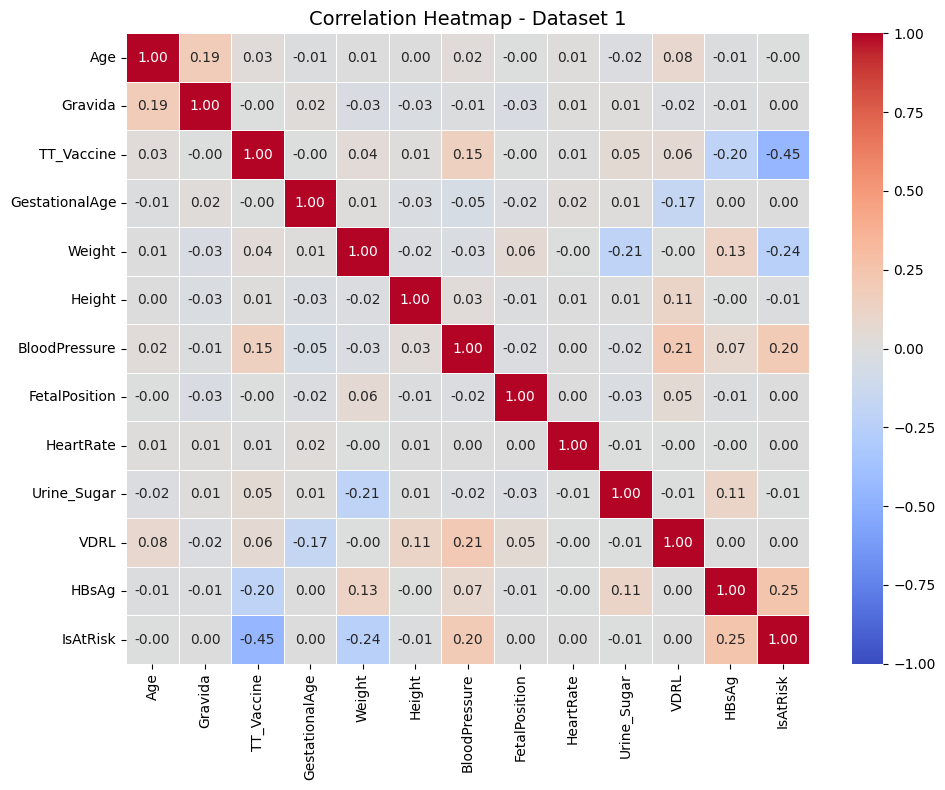

In [38]:
corr_df1 = df1.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_df1, 
    annot=True,         
    cmap="coolwarm",    
    fmt=".2f",           
    linewidths=0.5,     
    vmin=-1, vmax=1     
)

plt.title("Correlation Heatmap - Dataset 1", fontsize=14)
plt.tight_layout()
plt.show()

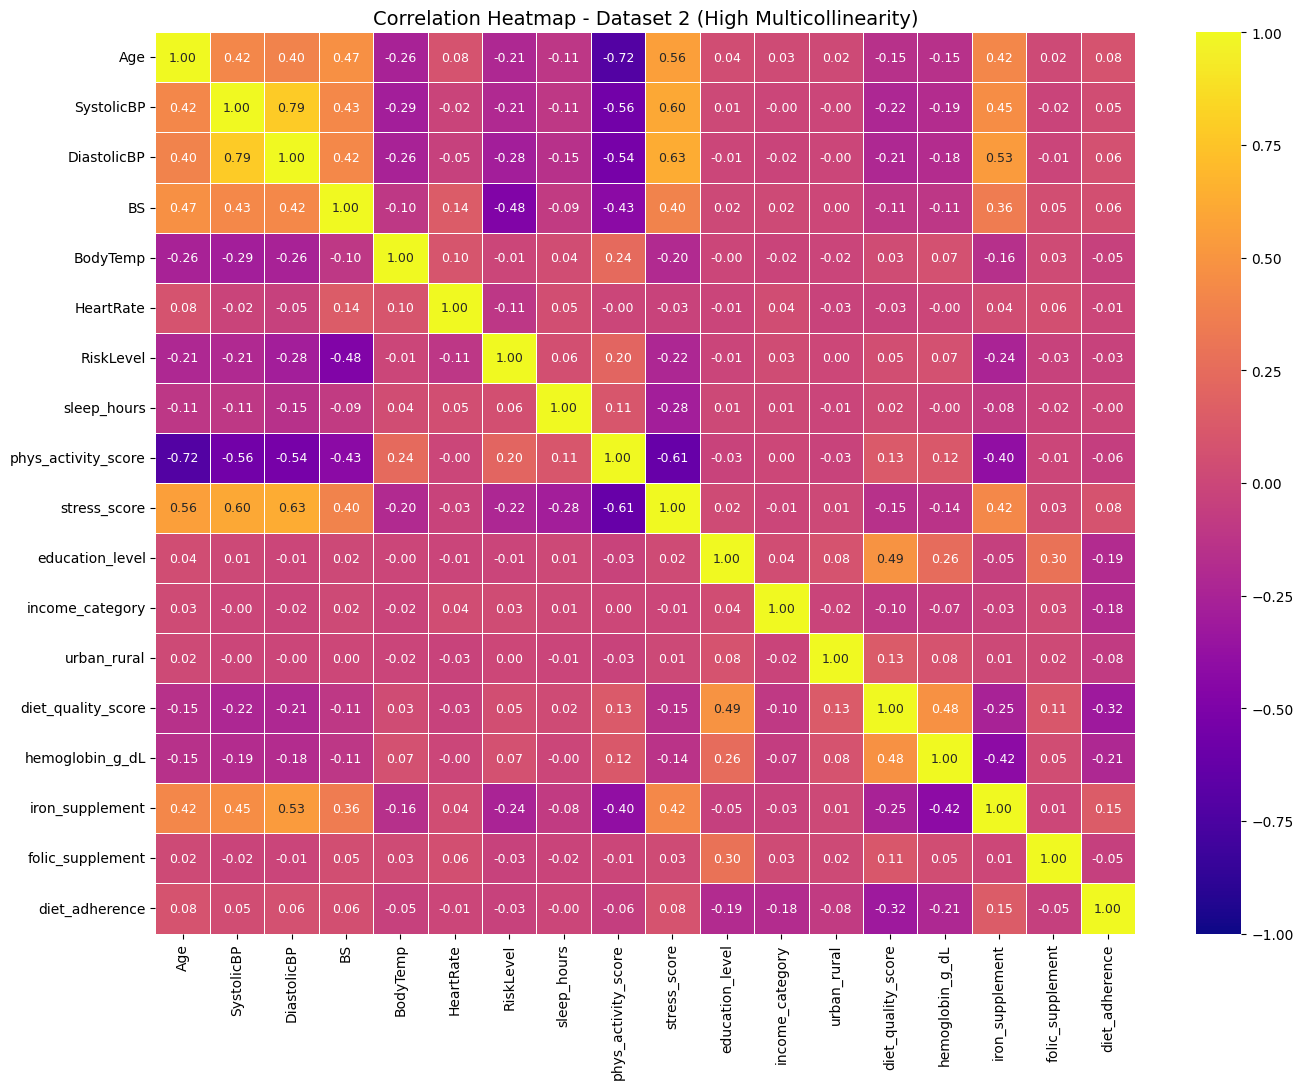

In [39]:
corr_df2 = df2.corr()
plt.figure(figsize=(14, 11))

sns.heatmap(
    corr_df2, 
    annot=True, 
    cmap="plasma", 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 9} 
)

plt.title("Correlation Heatmap - Dataset 2 (High Multicollinearity)", fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler as SS
temp = df1.copy()

scalers = [SS() for _ in range(2)]
ds = [temp, df2.copy()]
scaled_datas = [scalers[i].fit_transform(ds[i]) for i in range(2)]

for i in range(2):
    dbscan = DBSCAN(eps=3.0, min_samples=20)
    clusters = dbscan.fit_predict(scaled_datas[i])
    ds[i]['Cluster'] = clusters
    print(len(ds[i][ds[i]["Cluster"] == -1]))

76
557


1. As there are over 500+ outliers for dataset 2(~50%), no need for outlier removal
2. We will be further using SVM and XGboost to capture non-linear relationships between features in both datasets.

In [41]:
print(len(df1))
df1["Cluster"] = temp["Cluster"]
df1 = df1[df1["Cluster"] != -1]
print(len(df1))

998
922


In [42]:
print(df1["IsAtRisk"].value_counts())
print(df2["diet_adherence"].value_counts())

IsAtRisk
1    629
0    293
Name: count, dtype: int64
diet_adherence
0    697
2    160
1    157
Name: count, dtype: int64


In [43]:
df1 = df1.drop("Cluster", axis = 1)

In [44]:
df1.head()

,Age,Gravida,TT_Vaccine,GestationalAge,Weight,Height,BloodPressure,FetalPosition,HeartRate,Urine_Sugar,VDRL,HBsAg,IsAtRisk
1,0,0,0,10,2,3,1,1,3,1,0,0,1
2,7,1,1,10,9,2,3,1,2,1,1,0,0
3,2,0,0,6,6,0,1,1,0,1,0,0,1
4,4,0,2,8,3,4,6,1,2,1,1,0,1
5,2,0,1,6,5,2,0,1,1,1,0,0,0


In [45]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV

df1_train, df1_test = train_test_split(df1, test_size=0.2, random_state= 2026)
df2_train, df2_test = train_test_split(df2, test_size=0.2, random_state= 2026)

df1_test.to_csv('test1.csv', index=False)
df2_test.to_csv('test2.csv', index=False)

In [46]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import xgboost as xgb

In [47]:
X_train2 = df2_train.drop(columns=["diet_adherence"])
y_train2 = df2_train["diet_adherence"]

model2 = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5
)
model2.fit(X_train2, y_train2)
joblib.dump(model2, 'model2.pkl')
print("Model2 saved to model2.pkl")

Model2 saved to model2.pkl


In [48]:
print(model2.get_params())
print("Feature Importances:", model2.feature_importances_)

{'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}
Feature Importances: [0.01702258 0.0038884  0.00271835 0.00562785 0.         0.004

In [49]:
X_train1 = df1_train.drop(columns=["IsAtRisk"])
y_train1 = df1_train["IsAtRisk"]

clf = Pipeline([('scaler', SS()), ('svm', SVC())])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  
}

grid_search = GridSearchCV(clf, param_grid, cv=5, verbose=1)
grid_search.fit(X_train1, y_train1)

joblib.dump(grid_search.best_estimator_, 'model1.pkl')
print("Model1 saved to model1.pkl")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Model1 saved to model1.pkl


In [50]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
print("Support vectors:", best_model.named_steps['svm'].n_support_)

Best Parameters: {'svm__C': 10, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
Support vectors: [128 185]
